# Sensitivity — efectos_variables

Compare how different `efectos_variables` coefficients affect outcome dynamics.
Each scenario overrides the coefficients for one or both outcomes.
No treatment applied.

In [1]:
import sys
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '..')

from data_generation.simulator import DataSimulator
from data_generation.data_config import DATA_CONFIG

In [2]:
# Parámetros fijos
N_FIRMS   = 40
N_PERIODS = 300
SEED      = 2024

In [3]:
from itertools import product as iproduct

# -------------------------------------------------------------------------
# Coeficientes base calibrados por outcome
# empleados:        LR mean ~40   (rho=0.95, budget = 40 × 0.05 = 2.0)
# salario_promedio: LR mean ~170k (rho=0.98, budget = 170k × 0.02 = 3400)
# -------------------------------------------------------------------------

BASELINE_EMP = {
    'antiguedad':            0.15,   # LR +24 emp
    'exportadora':           2.0,    # LR +4.8 emp (exportadoras)
    'ratio_formalidad':      0.8,    # LR +10.7 emp
    'calidad_gerencial':     0.5,    # ±10 emp/sigma (heterogeneidad)
    'productividad_latente': 0.4,    # ±8  emp/sigma
    'propension_credito':    0.2,    # ±4  emp/sigma
    'sector': {'manufactura': 0.20, 'comercio': -0.10, 'servicios': -0.05, 'tecnologia': 0.10},
    'region': {'centro': 0.00, 'norte': -0.10, 'sur': -0.08, 'litoral': -0.05},
}

BASELINE_SAL = {
    'antiguedad':            250,    # LR +100k
    'exportadora':           5000,   # LR +30k
    'ratio_formalidad':      1500,   # LR +50k
    'calidad_gerencial':     500,    # ±25k/sigma
    'productividad_latente': 400,    # ±20k/sigma
    'propension_credito':    200,    # ±10k/sigma
    'sector': {'manufactura': 0, 'comercio': -5000, 'servicios': -3000, 'tecnologia': 15000},
    'region': {'centro': 0,    'norte': -8000, 'sur': -6000, 'litoral': -4000},
}

# -------------------------------------------------------------------------
# Modo de generación de escenarios
#   'oat'  → One-at-a-time: varía una variable, resto en baseline. Rápido.
#   'grid' → Producto cartesiano de MULTIPLIER_RANGES. Exhaustivo pero lento.
# -------------------------------------------------------------------------
SCENARIO_MODE = 'oat'   # cambiar a 'grid' para análisis completo

MULTIPLIER_RANGES = {
    'antiguedad':            [0.0, 0.5, 1.0, 2.0],
    'exportadora':           [0.0, 0.5, 1.0, 2.0],
    'ratio_formalidad':      [0.0, 0.5, 1.0, 2.0],
    'calidad_gerencial':     [0.0, 0.5, 1.0, 2.0],
    'productividad_latente': [0.0, 0.5, 1.0, 2.0],
    'propension_credito':    [0.0, 0.5, 1.0, 2.0],
    'sector_mult':           [0.0, 1.0, 2.0],
    'region_mult':           [0.0, 1.0, 2.0],
}

_var_names    = list(MULTIPLIER_RANGES.keys())
_baseline_vec = {v: 1.0 for v in _var_names}   # todos en baseline


def _build_efectos(baseline: dict, mults: dict) -> dict:
    return {
        'antiguedad':            baseline['antiguedad']            * mults['antiguedad'],
        'exportadora':           baseline['exportadora']           * mults['exportadora'],
        'ratio_formalidad':      baseline['ratio_formalidad']      * mults['ratio_formalidad'],
        'calidad_gerencial':     baseline['calidad_gerencial']     * mults['calidad_gerencial'],
        'productividad_latente': baseline['productividad_latente'] * mults['productividad_latente'],
        'propension_credito':    baseline['propension_credito']    * mults['propension_credito'],
        'sector': {k: v * mults['sector_mult'] for k, v in baseline['sector'].items()},
        'region': {k: v * mults['region_mult'] for k, v in baseline['region'].items()},
    }


def _make_scenario(name: str, mults: dict) -> dict:
    return {
        'name':  name,
        'combo': mults.copy(),
        'efectos_variables': {
            'empleados':        _build_efectos(BASELINE_EMP, mults),
            'salario_promedio': _build_efectos(BASELINE_SAL, mults),
        }
    }


if SCENARIO_MODE == 'oat':
    # Escenario base + un escenario por cada (variable, valor) con resto en baseline
    SCENARIOS = [_make_scenario('baseline (todo activo)', _baseline_vec)]
    for var in _var_names:
        for val in MULTIPLIER_RANGES[var]:
            if val == 1.0:
                continue  # ya está en baseline
            mults = {**_baseline_vec, var: val}
            SCENARIOS.append(_make_scenario(f'{var}={val}', mults))

elif SCENARIO_MODE == 'grid':
    combos = list(iproduct(*[MULTIPLIER_RANGES[v] for v in _var_names]))
    SCENARIOS = [
        _make_scenario(str(dict(zip(_var_names, c))), dict(zip(_var_names, c)))
        for c in combos
    ]

print(f"Modo: {SCENARIO_MODE} | Escenarios: {len(SCENARIOS)}")

Modo: oat | Escenarios: 23


In [4]:
def build_config(scenario: dict) -> dict:
    cfg = copy.deepcopy(DATA_CONFIG)
    cfg.update({
        'n_empresas':                N_FIRMS,
        'n_periodos':                N_PERIODS,
        'n_cohortes':                0,
        'cupo_por_cohorte':          [],
        'periodo_inicio_programa':   N_PERIODS,
        'min_periodos_pre_programa': N_PERIODS,
        'random_seed':               SEED,
    })
    for outcome, efv in scenario['efectos_variables'].items():
        cfg['dinamica_outcomes'][outcome]['efectos_variables'] = efv
    return cfg


panels = {}
for scenario in SCENARIOS:
    cfg   = build_config(scenario)
    sim   = DataSimulator(cfg)
    panel = sim.simulate()
    panels[scenario['name']] = panel
    print(f"[{scenario['name']}] done")

/home/bbas-entelai/Dev/personal-projects/PaperEvaluacionImpacto/repo/notebooks/../data_generation/simulator.py:518: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  firms[f'{outcome}_{t}'] = new_values
/home/bbas-entelai/Dev/personal-projects/PaperEvaluacionImpacto/repo/notebooks/../data_generation/simulator.py:518: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  firms[f'{outcome}_{t}'] = new_values
/home/bbas-entelai/Dev/personal-projects/PaperEvaluacionImpacto/repo/notebooks/../data_generation/simulator.py:518: PerformanceWarning: 

[baseline (todo activo)] done


/home/bbas-entelai/Dev/personal-projects/PaperEvaluacionImpacto/repo/notebooks/../data_generation/simulator.py:518: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  firms[f'{outcome}_{t}'] = new_values
/home/bbas-entelai/Dev/personal-projects/PaperEvaluacionImpacto/repo/notebooks/../data_generation/simulator.py:518: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  firms[f'{outcome}_{t}'] = new_values
/home/bbas-entelai/Dev/personal-projects/PaperEvaluacionImpacto/repo/notebooks/../data_generation/simulator.py:518: PerformanceWarning: 

[antiguedad=0.0] done


/home/bbas-entelai/Dev/personal-projects/PaperEvaluacionImpacto/repo/notebooks/../data_generation/simulator.py:518: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  firms[f'{outcome}_{t}'] = new_values
/home/bbas-entelai/Dev/personal-projects/PaperEvaluacionImpacto/repo/notebooks/../data_generation/simulator.py:518: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  firms[f'{outcome}_{t}'] = new_values
/home/bbas-entelai/Dev/personal-projects/PaperEvaluacionImpacto/repo/notebooks/../data_generation/simulator.py:518: PerformanceWarning: 

...

[sector_mult=2.0] done


/home/bbas-entelai/Dev/personal-projects/PaperEvaluacionImpacto/repo/notebooks/../data_generation/simulator.py:518: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  firms[f'{outcome}_{t}'] = new_values
/home/bbas-entelai/Dev/personal-projects/PaperEvaluacionImpacto/repo/notebooks/../data_generation/simulator.py:518: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  firms[f'{outcome}_{t}'] = new_values
/home/bbas-entelai/Dev/personal-projects/PaperEvaluacionImpacto/repo/notebooks/../data_generation/simulator.py:518: PerformanceWarning: 

[region_mult=0.0] done


/home/bbas-entelai/Dev/personal-projects/PaperEvaluacionImpacto/repo/notebooks/../data_generation/simulator.py:518: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  firms[f'{outcome}_{t}'] = new_values
/home/bbas-entelai/Dev/personal-projects/PaperEvaluacionImpacto/repo/notebooks/../data_generation/simulator.py:518: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  firms[f'{outcome}_{t}'] = new_values
/home/bbas-entelai/Dev/personal-projects/PaperEvaluacionImpacto/repo/notebooks/../data_generation/simulator.py:518: PerformanceWarning: 

[region_mult=2.0] done


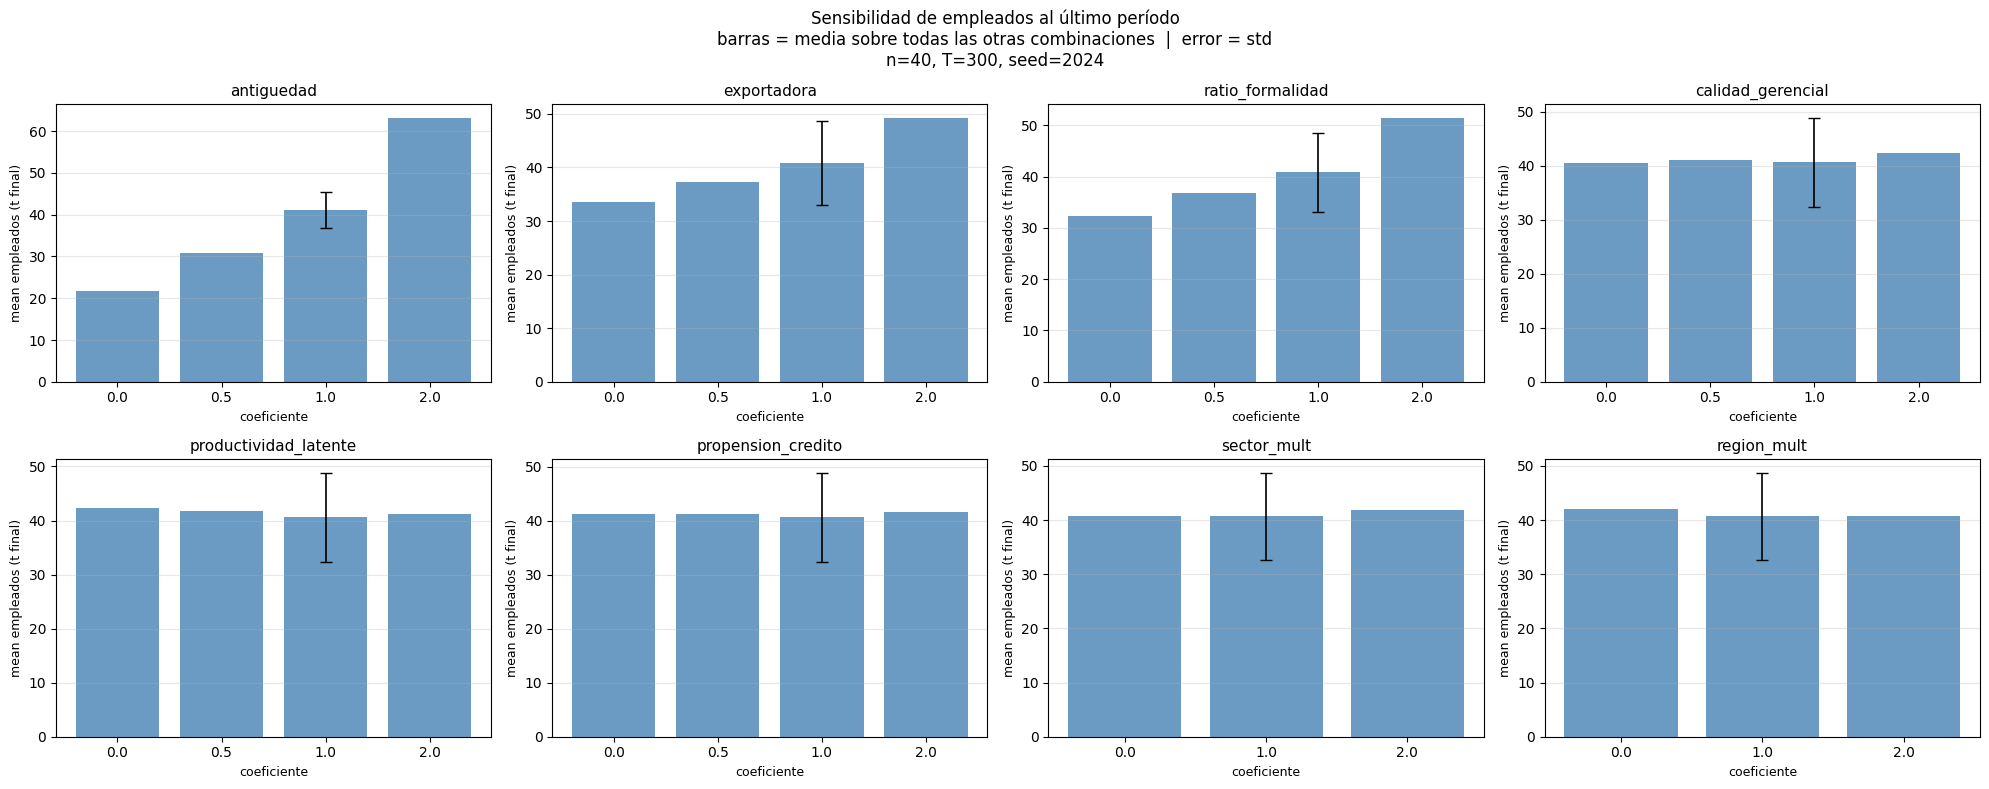

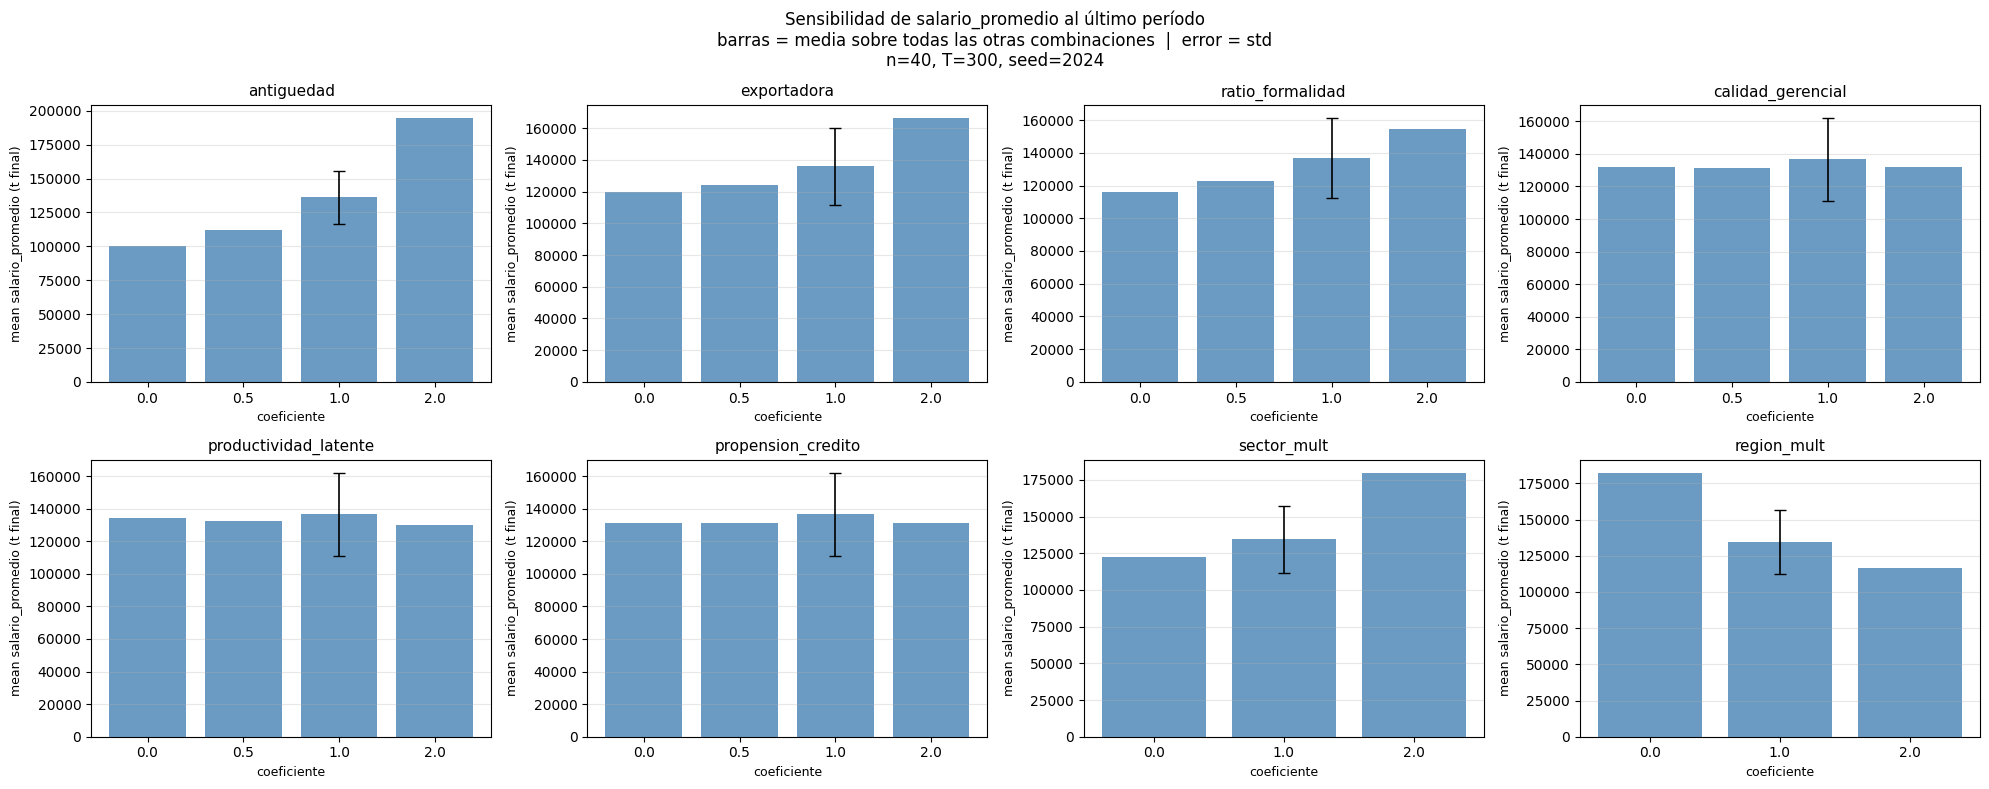

In [5]:
outcomes = list(DATA_CONFIG['dinamica_outcomes'].keys())

# Build results DataFrame: one row per scenario, columns = mean per period per outcome
records = []
for scenario in SCENARIOS:
    row = {'name': scenario['name'], **scenario['combo']}
    panel = panels[scenario['name']]
    for outcome in outcomes:
        # Mean over all firms and all periods
        row[f'{outcome}_mean_global'] = panel[outcome].mean()
        # Mean at last period
        row[f'{outcome}_mean_last'] = panel[panel['t'] == panel['t'].max()][outcome].mean()
    records.append(row)

results_df = pd.DataFrame(records)

# One-at-a-time sensitivity: for each variable, show how outcome mean varies
# across its values (averaged over all other variable combinations)
for outcome in outcomes:
    n_vars = len(_var_names)
    fig, axes = plt.subplots(2, (n_vars + 1) // 2, figsize=(5 * ((n_vars + 1) // 2), 8))
    axes = axes.flatten()

    for ax, var in zip(axes, _var_names):
        grouped = results_df.groupby(var)[f'{outcome}_mean_last'].agg(['mean', 'std'])
        ax.bar(
            grouped.index.astype(str),
            grouped['mean'],
            yerr=grouped['std'],
            capsize=4,
            color='steelblue',
            alpha=0.8,
            error_kw={'elinewidth': 1.2}
        )
        ax.set_title(var, fontsize=11)
        ax.set_xlabel('coeficiente', fontsize=9)
        ax.set_ylabel(f'mean {outcome} (t final)', fontsize=9)
        ax.grid(axis='y', alpha=0.3)

    # Hide unused axes
    for ax in axes[n_vars:]:
        ax.set_visible(False)

    fig.suptitle(
        f'Sensibilidad de {outcome} al último período\n'
        f'barras = media sobre todas las otras combinaciones  |  error = std\n'
        f'n={N_FIRMS}, T={N_PERIODS}, seed={SEED}',
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

In [6]:
for outcome in outcomes:
    cols = _var_names + [f'{outcome}_mean_last', f'{outcome}_mean_global']
    print(f"\n{'='*70}")
    print(f"  {outcome}")
    print(f"{'='*70}")
    print(results_df[cols].sort_values(f'{outcome}_mean_last', ascending=False).round(3).to_string(index=False))


  empleados
 antiguedad  exportadora  ratio_formalidad  calidad_gerencial  productividad_latente  propension_credito  sector_mult  region_mult  empleados_mean_last  empleados_mean_global
        2.0          1.0               1.0                1.0                    1.0                 1.0          1.0          1.0               63.250                 59.624
        1.0          1.0               2.0                1.0                    1.0                 1.0          1.0          1.0               51.500                 48.501
        1.0          2.0               1.0                1.0                    1.0                 1.0          1.0          1.0               49.300                 46.484
        1.0          1.0               1.0                2.0                    1.0                 1.0          1.0          1.0               42.425                 40.089
        1.0          1.0               1.0                1.0                    0.0                 1.0        